# Ensemble Model: XGBoost Classifier on Vehicle Coupon Recommendation Dataset

This notebook implements an **XGBoost (Extreme Gradient Boosting)** ensemble classifier to predict whether a driver will accept a coupon. XGBoost is a boosting-based ensemble method that builds trees sequentially, where each subsequent tree corrects the errors of the previous ones. It is known for its high performance, regularization capabilities, and efficient handling of missing values. We will perform data preprocessing, model training with hyperparameter tuning via RandomizedSearchCV, and evaluation with classification metrics and visualizations.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, roc_curve
import pickle
import json
import os

## 1. Data Loading

In [40]:
# Load the dataset
try:
    df = pd.read_csv('../in-vehicle-coupon-recommendation.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found! Please check the path.")

# Display info to identify columns
df.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar    

In [41]:
# Display first few rows
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [42]:
# Drop duplicates
df = df.drop_duplicates()

# Drop 'car' column if >90% null
if 'car' in df.columns and df['car'].isnull().mean() > 0.9:
    print("Dropping 'car' column due to >90% missing values.")
    df = df.drop(columns=['car'])

# --- Ordinal Encoding for ordered categorical columns ---
FREQUENCY_ORDER = ['never', 'less1', '1~3', '4~8', 'gt8']
AGE_ORDER = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
INCOME_ORDER = [
    'Less than $12500', '$12500 - $24999', '$25000 - $37499',
    '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
    '$75000 - $87499', '$87500 - $99999', '$100000 or More'
]
EXPIRATION_ORDER = ['2h', '1d']
TIME_MAP = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}
FREQUENCY_COLS = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Map frequency columns to numeric
freq_map = {v: i for i, v in enumerate(FREQUENCY_ORDER)}
for col in FREQUENCY_COLS:
    if col in df.columns:
        df[col] = df[col].map(freq_map)

# Map age to numeric
age_map = {v: i for i, v in enumerate(AGE_ORDER)}
if 'age' in df.columns:
    df['age'] = df['age'].map(age_map)

# Map income to numeric
income_map = {v: i for i, v in enumerate(INCOME_ORDER)}
if 'income' in df.columns:
    df['income'] = df['income'].map(income_map)

# Map expiration to numeric
exp_map = {v: i for i, v in enumerate(EXPIRATION_ORDER)}
if 'expiration' in df.columns:
    df['expiration'] = df['expiration'].map(exp_map)

# Map time to numeric hour
if 'time' in df.columns:
    df['time'] = df['time'].map(TIME_MAP)

# --- Feature Engineering ---
freq_available = [c for c in FREQUENCY_COLS if c in df.columns]
if freq_available:
    df['total_visits'] = df[freq_available].sum(axis=1)
    print(f"Added 'total_visits' feature (sum of {freq_available})")

if 'passanger' in df.columns:
    df['is_alone'] = (df['passanger'] == 'Alone').astype(int)
    print("Added 'is_alone' feature")

# Separate Target and Features
X = df.drop(columns=['Y'])
y = df['Y']

# Identify Numerical and Categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

Dropping 'car' column due to >90% missing values.
Added 'total_visits' feature (sum of ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'])
Added 'is_alone' feature
Numerical Features (18): ['temperature', 'time', 'expiration', 'age', 'has_children', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'total_visits', 'is_alone']
Categorical Features (8): ['destination', 'passanger', 'weather', 'coupon', 'gender', 'maritalStatus', 'education', 'occupation']


## 2. Data Preprocessing

In [43]:
# Define Preprocessing Pipeline
# XGBoost can handle missing values internally, but we still preprocess
# for consistency with the other model pipelines in this project.

# Numerical Transformer: Impute median (if any missing) -> Scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer: Impute 'missing' -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## 3. Train-Test Split

In [44]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create Model Pipeline
xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

# Hyperparameter grid for RandomizedSearchCV
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500, 700],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, 9, 11],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.3, 0.5],
    'classifier__reg_alpha': [0, 0.01, 0.1, 1],
    'classifier__reg_lambda': [0.5, 1, 1.5, 2],
}

# RandomizedSearchCV: 30 iterations, 5-fold CV, f1_weighted scoring
search = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV Score (f1_weighted): {search.best_score_:.4f}")

# Use best estimator for predictions
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Model Trained Successfully!")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'classifier__subsample': 1.0, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}
Best CV Score (f1_weighted): 0.7619
Model Trained Successfully!


## 5. Evaluation

Test Set Accuracy: 0.7732
ROC-AUC Score: 0.8452


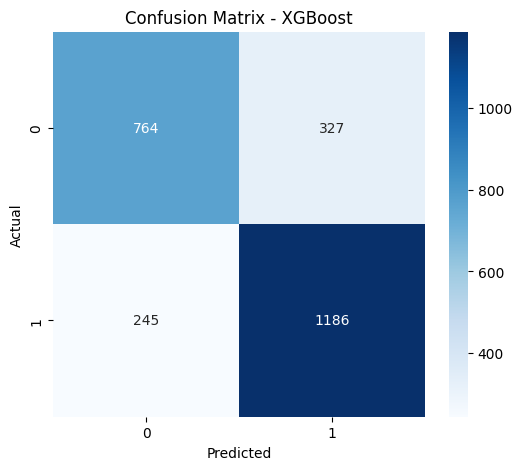

In [45]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. ROC Curve

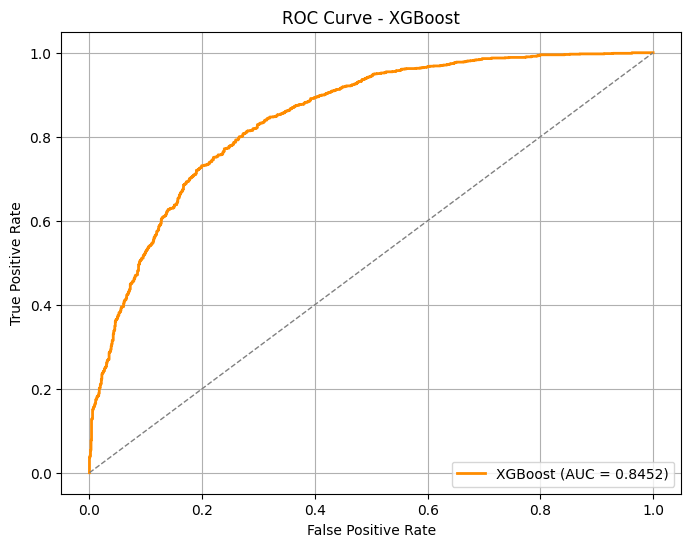

In [46]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 7. Visualization: Number of Estimators vs Accuracy

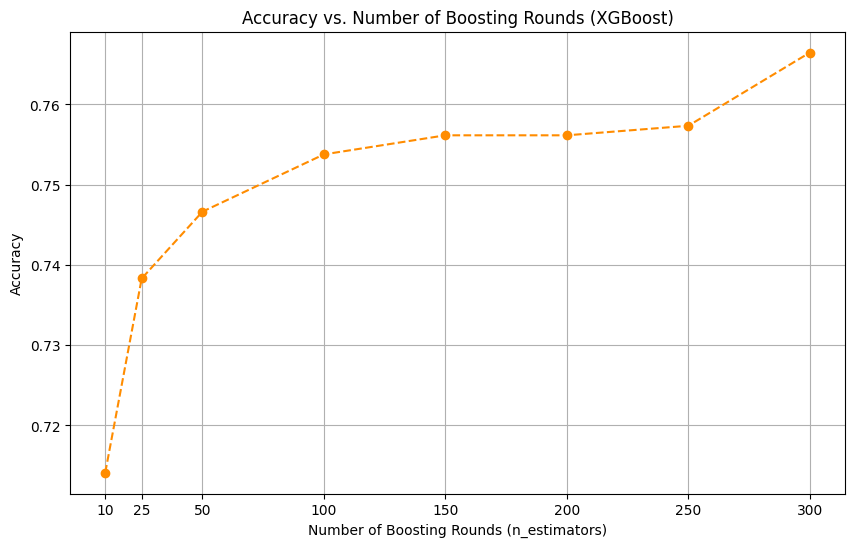

In [47]:
# Visualize how test accuracy changes with number of boosting rounds
n_estimators_range = [10, 25, 50, 100, 150, 200, 250, 300]
acc_scores = []

for n in n_estimators_range:
    temp_clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=n, random_state=42,
            eval_metric='logloss', n_jobs=-1
        ))
    ])
    temp_clf.fit(X_train, y_train)
    acc = temp_clf.score(X_test, y_test)
    acc_scores.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, acc_scores, marker='o', linestyle='dashed', color='darkorange')
plt.title('Accuracy vs. Number of Boosting Rounds (XGBoost)')
plt.xlabel('Number of Boosting Rounds (n_estimators)')
plt.ylabel('Accuracy')
plt.xticks(n_estimators_range)
plt.grid(True)
plt.show()

## 8. Learning Rate vs Accuracy

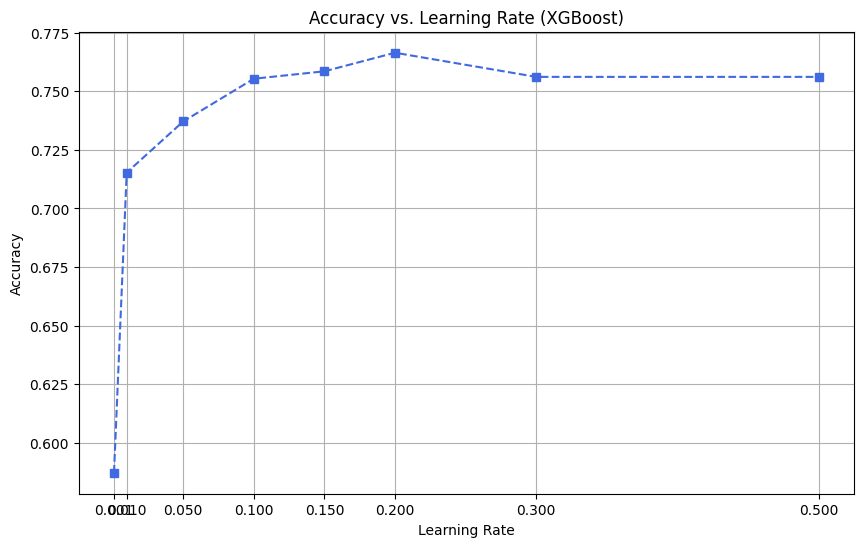

In [48]:
# Track how accuracy changes with different learning rates
lr_range = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
lr_acc_scores = []

for lr in lr_range:
    temp_clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=200, learning_rate=lr, random_state=42,
            eval_metric='logloss', n_jobs=-1
        ))
    ])
    temp_clf.fit(X_train, y_train)
    acc = temp_clf.score(X_test, y_test)
    lr_acc_scores.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(lr_range, lr_acc_scores, marker='s', linestyle='dashed', color='royalblue')
plt.title('Accuracy vs. Learning Rate (XGBoost)')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.xticks(lr_range)
plt.grid(True)
plt.show()

## 9. Feature Importance

/var/folders/1g/qb6xwhq93b57bjwbpxmxdngm0000gn/T/ipykernel_99950/2881039852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='YlOrRd_r')


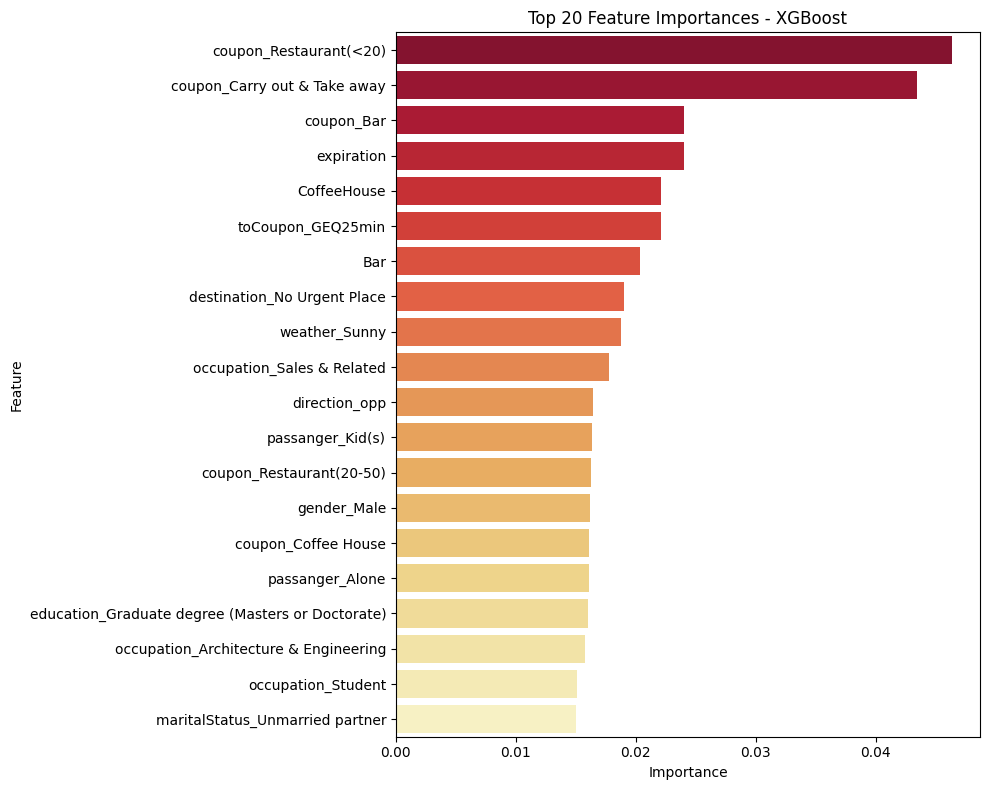

In [49]:
# Get the trained XGBoost classifier from the best pipeline
xgb_model = best_model.named_steps['classifier']
preprocessor_fitted = best_model.named_steps['preprocessor']

# Get feature names from the preprocessor
num_features = numerical_cols
cat_features = preprocessor_fitted.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = num_features + cat_features

# Feature importances
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(20)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='YlOrRd_r')
plt.title('Top 20 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

## 10. Summary

| Aspect | Details |
| --- | --- |
| **Model** | XGBoost Classifier (boosting ensemble of Decision Trees using gradient boosting) |
| **Tuning** | RandomizedSearchCV (5-fold CV) over n_estimators, max_depth, learning_rate, subsample, colsample_bytree, reg_alpha, reg_lambda |
| **Evaluation** | Accuracy, Classification Report, Confusion Matrix, ROC-AUC |
| **Advantages** | Sequential error correction via boosting, built-in L1/L2 regularization, handles missing values, highly scalable and efficient |